In [1]:
import torch
from torch import nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [4]:
import os
def walk_through_dir(dir_path):

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

Random image path: data\pizza_steak_sushi\train\pizza\2687575.jpg
Image class: pizza
Image height: 384
Image width: 512


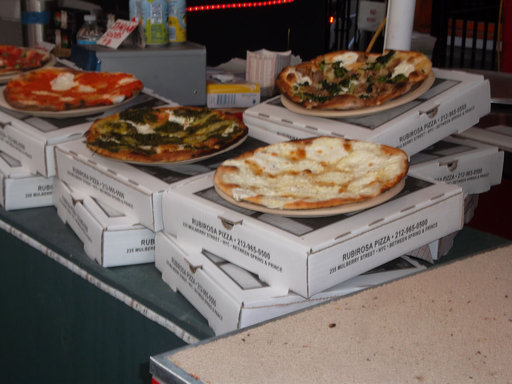

In [21]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

In [23]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [34]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [ ]:
import matplotlib.pyplot as plt

def plot_transformed_images(image_paths,transform, n = 3 ,seed = 42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k = n)

    for image_path in random_image_paths: 
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


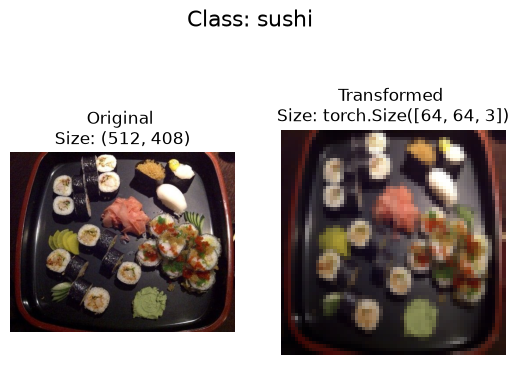

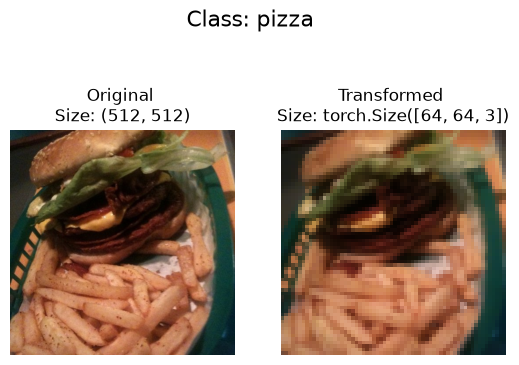

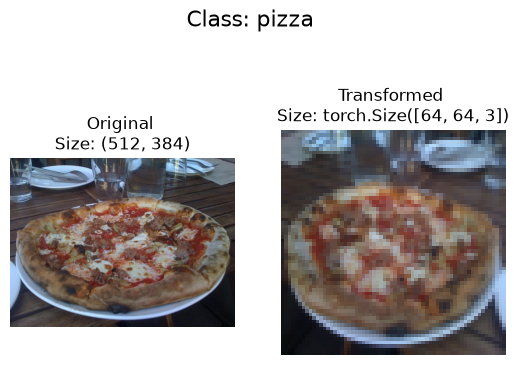

In [36]:
plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)

In [37]:
from torchvision import datasets

train_data = datasets.ImageFolder(root = train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [40]:
class_names = train_data.classes
class_names


['pizza', 'steak', 'sushi']

In [41]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [43]:
img,label = train_data[0][0] , train_data[0][1]
img,label,img.shape

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [45]:
import os
os.cpu_count()

24

In [47]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size = 1,
                              num_workers= 10,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size= 1,
                             num_workers= 10,
                             shuffle= False)

test_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21399f33200>,
 <torch.utils.data.dataloader.DataLoader at 0x21399f33200>)

In [48]:
img,label = next(iter(train_dataloader))

img,label

(tensor([[[[0.8078, 0.8118, 0.8000,  ..., 0.8392, 0.8196, 0.7922],
           [0.7961, 0.7961, 0.7843,  ..., 0.8392, 0.8353, 0.8157],
           [0.7882, 0.7843, 0.7686,  ..., 0.8353, 0.8353, 0.8353],
           ...,
           [0.5686, 0.5725, 0.6510,  ..., 0.7294, 0.7569, 0.7608],
           [0.7451, 0.7451, 0.7922,  ..., 0.7333, 0.7529, 0.7569],
           [0.8118, 0.8275, 0.8549,  ..., 0.7137, 0.7608, 0.7529]],
 
          [[0.6039, 0.6078, 0.6000,  ..., 0.6510, 0.6392, 0.6118],
           [0.5882, 0.5843, 0.5765,  ..., 0.6471, 0.6510, 0.6353],
           [0.5725, 0.5647, 0.5490,  ..., 0.6392, 0.6510, 0.6510],
           ...,
           [0.4078, 0.3922, 0.4549,  ..., 0.5765, 0.6000, 0.5961],
           [0.5765, 0.5843, 0.6157,  ..., 0.6196, 0.6118, 0.5922],
           [0.6314, 0.6471, 0.6667,  ..., 0.6039, 0.6431, 0.6039]],
 
          [[0.2863, 0.2706, 0.2588,  ..., 0.4118, 0.4235, 0.3961],
           [0.2667, 0.2549, 0.2471,  ..., 0.4157, 0.4235, 0.4078],
           [0.2471, 0.23

In [50]:
img.shape,label.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

In [ ]:
target_directory = train_dir
print(f"Target directory: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print(f"Class names found: {class_names_found}")

In [52]:
from typing import Tuple, List, Dict
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:

    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    

    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")
        
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [53]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [55]:
# Writing custom Dataset
from torch.utils.data import Dataset
import pathlib

class ImageFolderCustom(Dataset):

    def __init__(self,targ_dir: str,transform = None) -> None :
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        self.transform = transform

        self.classes,self.class_to_idx = find_classes(targ_dir)

    def load_image(self,index: int) -> Image.Image:

        image_path = self.paths[index]

        return Image.open(image_path)
    
    def __len__(self) -> int :

        return len(self.paths)
    
    def __getitem__(self, index :int) -> int :

        img = self.load_image(index)

        class_name = self.paths[index].parent.name

        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        
        else:
            return img, class_idx
        


        

In [58]:
from torchvision import transforms

train_advance_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_advance_transforms = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor()
])


In [72]:
from torchvision import datasets

train_data_advance = datasets.ImageFolder(root=train_dir,
                                        transform=train_advance_transforms)
test_data_advance = datasets.ImageFolder(root=test_dir,
                                         transform=test_advance_transforms)


In [73]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_advance = DataLoader(train_data_advance, 
                                     batch_size=BATCH_SIZE, 
                                     shuffle=True, 
                                     num_workers=NUM_WORKERS)

test_dataloader_advance = DataLoader(test_data_advance, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

Creating DataLoader's with batch size 32 and 24 workers.


In [129]:
class TinyVGG(nn.Module):

    def __init__(self,input_shape : int, output_shape: int , hidden_units : int =10) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape,
                      out_channels=hidden_units,
                      kernel_size= 3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      stride=1,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_units *16*16,
                      out_features= output_shape)
        )

    def forward(self,x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [130]:
model_0 = TinyVGG(input_shape= 3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

In [131]:
len(class_names)

3

In [132]:
img_batch, label_batch = next(iter(train_dataloader_advance))


In [133]:
img_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [134]:
img_single  = img_batch[0].unsqueeze(dim = 0)
img_single.shape


torch.Size([1, 3, 64, 64])

In [135]:
label_single = label_batch[0]
label_single

tensor(0)

In [136]:
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

    pred = torch.softmax(pred,dim =1)

    pred = torch.argmax(pred)

    pred = class_names[pred]
pred

'sushi'

In [137]:
from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [138]:
def train_step(model : torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer):
    
    model.train()

    train_loss = 0
    train_acc = 0

    for batch,(X,y) in enumerate(dataloader):

        X = X.to(device)
        y = y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred,y)

        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)

        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

        print(f"---{batch}")

    train_loss /= len(dataloader)

    train_acc /= len(dataloader)

    return train_loss,train_acc

In [139]:
def test_step(model : torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module):
    model.eval()
    with torch.inference_mode():

        test_loss = 0
        test_acc = 0

        for X,y in dataloader:

            X = X.to(device)
            y = y.to(device)

            y_preds = model(X)

            test_loss += loss_fn(y_preds,y)

            test_pred_labels = y_preds.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

    return test_loss,test_acc

In [140]:
def train_model(model : torch.nn.Module,
                train_dataloader : torch.utils.data.DataLoader,
                test_dataloader : torch.utils.data.DataLoader,
                optimizer : torch.optim.Optimizer,
                loss_fn : torch.nn.Module,
                epochs : int = 5):
    
    results = {"train_loss" : [],
               "train_acc" : [],
               "test_loss" : [],
               "test_acc" : []
               }
    
    from tqdm.auto import tqdm

    for epoch in tqdm(range(epochs)):

        train_loss,train_acc = train_step(model = model,
                                dataloader= train_dataloader,
                                loss_fn= loss_fn,
                                optimizer= optimizer)
        
        test_loss,test_acc = test_step(model = model,
                                       dataloader=test_dataloader,
                                       loss_fn= loss_fn)
        
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}")
        

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results


In [ ]:
loss_fn =  nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr = 0.0005)

In [142]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)

epochs = 50


from timeit import default_timer as timer 
start_time = timer()


model_0_results = train_model(model=model_0, 
                        train_dataloader=train_dataloader_advance,
                        test_dataloader=test_dataloader_advance,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=epochs)


end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")




  0%|          | 0/50 [00:00<?, ?it/s]

---0
---1
---2
---3
---4
---5
---6
---7


  2%|▏         | 1/50 [00:15<12:55, 15.83s/it]

Epoch: 1 | train_loss: 1.1076 | train_acc: 0.2812 | test_loss: 1.1029 | test_acc: 0.2604
---0
---1
---2
---3
---4
---5
---6
---7


  4%|▍         | 2/50 [00:31<12:26, 15.55s/it]

...

Epoch: 48 | train_loss: 0.9663 | train_acc: 0.4922 | test_loss: 0.9997 | test_acc: 0.4545
---0
---1
---2
---3
---4
---5
---6
---7


 98%|█████████▊| 49/50 [13:51<00:17, 17.25s/it]

Epoch: 49 | train_loss: 0.9096 | train_acc: 0.5781 | test_loss: 1.0790 | test_acc: 0.3835
---0
---1
---2
---3
---4
---5
---6
---7


100%|██████████| 50/50 [14:08<00:00, 16.97s/it]

Epoch: 50 | train_loss: 0.9342 | train_acc: 0.4961 | test_loss: 1.1322 | test_acc: 0.3835
Total training time: 848.294 seconds


In [127]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    
    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

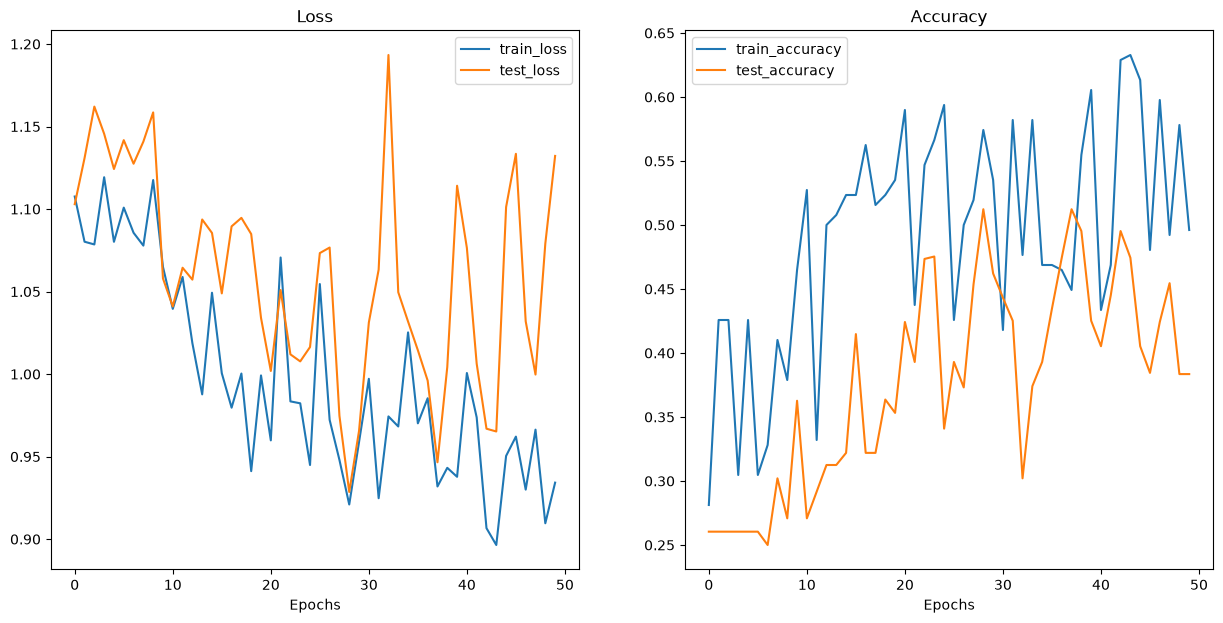

In [143]:
plot_loss_curves(model_0_results)

In [ ]:

def pred_and_plot_image(model: torch.nn.Module, 
                        image_path: str, 
                        class_names: List[str] = None, 
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    
    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    
    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255. 
    
    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)
    
    # 4. Make sure the model is on the target device
    model.to(device)
    
    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)
    
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))
        
    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

In [144]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "TinyVGG_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_0.state_dict(),f =MODEL_SAVE_PATH)